# Relevant Papers
NA

# Import Necessary Libraries

In [4]:
import numpy as np
from sklearn.datasets import load_iris, make_blobs
import matplotlib.pyplot as plt

from artlib import FuzzyART, ARTMAP, FusionART, normalize

# Dataset Initalization
In this example we just define an array of strings we would like to cluster

In [5]:
x_ = np.arange(0.0,4.0, 0.01)
x = x_+0.5
y = np.sin(x)+np.cos(x**2)+np.log(x**3)+np.cos(x)*np.log(x**2)

x_norm, _, _ = normalize(x)
y_norm, _, _ = normalize(y)
X_,y_ = x_norm.reshape((-1,1)), y_norm.reshape((-1,1))
print("Data has shape:", X_.shape)


Data has shape: (400, 1)


## Regression with Fusion Art

In the example below, we initialize two inital fuzzy ART model with the following parameters  

- `rho`: The vigilance parameter, controlling the level of similarity required for vectors to belong to the same cluster.
- `alpha`: A parameter that controls noise suppression, helping to handle noisy data more effectively.
- `beta`: The learning rate, which influences the speed of adaptation and category refinement.

We then prepare the data for each fuzzy art model.  

We then instantuate a Fusion ART model with the two FuzzyART models, along with gamma_values 0.5 for each model

We then join the channel data and then cluster the data with fit_predict  

After the clustering we then grab the X data and predict the regression using `predict_regression`  
Afterwords we plot the data using matplot lib  

Prepared data has shape: (400, 2)
52 clusters found


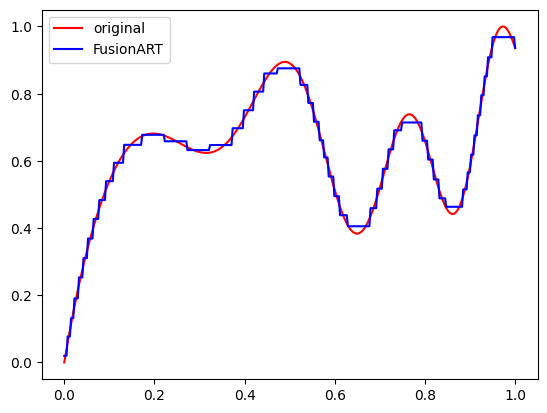

In [6]:
params = {
    "rho": 0.95,
    "alpha": 0.0,
    "beta": 1.0
}
art_a = FuzzyART(**params)
art_b = FuzzyART(**params)

X = art_a.prepare_data(X_)
y = art_b.prepare_data(y_)
print("Prepared data has shape:", X.shape)

cls = FusionART([art_a, art_b], gamma_values=np.array([0.5, 0.5]), channel_dims=[2, 2])

Xy = cls.join_channel_data(channel_data=[X, y])

cls = cls.fit(Xy)

print(f"{cls.n_clusters} clusters found")

X_no_y = cls.join_channel_data(channel_data=[X], skip_channels=[-1])

y_pred = cls.predict_regression(X_no_y, target_channels=[-1])

plt.plot(X_, y_, 'r-', label="original")
plt.plot(X_, y_pred, "b-", label="FusionART")
plt.legend()
plt.show()
